Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Definicion de la funcion

In [2]:
def fft_mariposa(x):
    N = len(x)

    # Caso base: si la señal es de 1 punto, la FFT es el punto mismo
    if N <= 1:
        return x

    # Verificación de que N sea potencia de 2
    if N % 2 > 0:
        raise ValueError("El tamaño debe ser potencia de 2 (ej. 1024)")

    # 1. DIVIDIR: Separamos en índices pares e impares
    pares = fft_mariposa(x[0::2])
    impares = fft_mariposa(x[1::2])

    # 2. CONQUISTAR: Aplicamos las mariposas
    resultado = np.zeros(N, dtype=complex)

    for k in range(N // 2):
        # Factor de Giro (Twiddle Factor) W = e^(-j * 2pi * k / N)
        twiddle = np.exp(-2j * np.pi * k / N)

        # OPERACIÓN DE MARIPOSA
        A = pares[k]
        B = twiddle * impares[k]

        resultado[k] = A + B
        resultado[k + N//2] = A - B

    return resultado

Codigo principal

In [3]:
# --- CONFIGURACIÓN DE LA SEÑAL ---
fs = 1024  # Frecuencia de muestreo
t = np.linspace(0, 1, fs, endpoint=False)
# Creamos una señal con dos frecuencias: 50Hz y 120Hz para que el gráfico sea más interesante
señal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)

# --- CÁLCULOS ---
fft_propia = fft_mariposa(señal)
fft_numpy = np.fft.fft(señal)

Graficacion y comparacion con funcion de NumPy

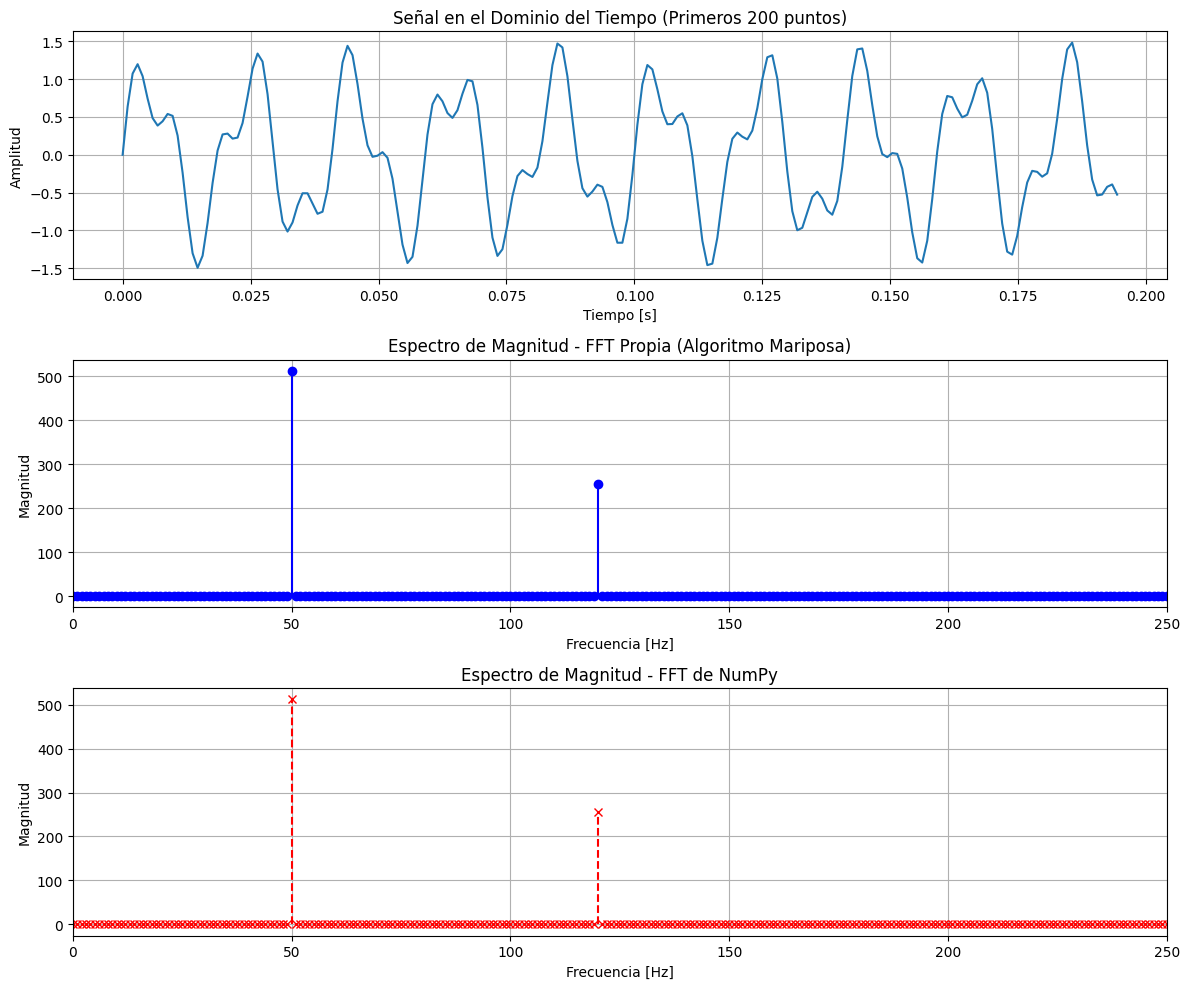

In [4]:
# Eje de frecuencias
frecuencias = np.fft.fftfreq(fs, 1/fs)

# Para graficar, tomamos solo la mitad positiva del espectro (0 a fs/2)
n_mitad = fs // 2
f_plot = frecuencias[:n_mitad]
mag_propia = np.abs(fft_propia[:n_mitad])
mag_numpy = np.abs(fft_numpy[:n_mitad])

# --- GRAFICACIÓN ---
plt.figure(figsize=(12, 10))

# 1. Señal en el tiempo
plt.subplot(3, 1, 1)
plt.plot(t[:200], señal[:200]) # Mostramos solo una parte para ver la forma de onda
plt.title("Señal en el Dominio del Tiempo (Primeros 200 puntos)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

# 2. Magnitud FFT Propia
plt.subplot(3, 1, 2)
plt.stem(f_plot, mag_propia, linefmt='b-', markerfmt='bo', basefmt=' ')
plt.title("Espectro de Magnitud - FFT Propia (Algoritmo Mariposa)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 250) # Hacemos zoom en las frecuencias de interés
plt.grid(True)

# 3. Magnitud FFT NumPy
plt.subplot(3, 1, 3)
plt.stem(f_plot, mag_numpy, linefmt='r--', markerfmt='rx', basefmt=' ')
plt.title("Espectro de Magnitud - FFT de NumPy")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 250)
plt.grid(True)

plt.tight_layout()
plt.show()



Comparacion numerica

In [5]:
# Verificación numérica
print(f"¿Coinciden los resultados?: {np.allclose(fft_propia, fft_numpy)}")

¿Coinciden los resultados?: True


Ejemplo de Diagrama de Mariposas con N = 16

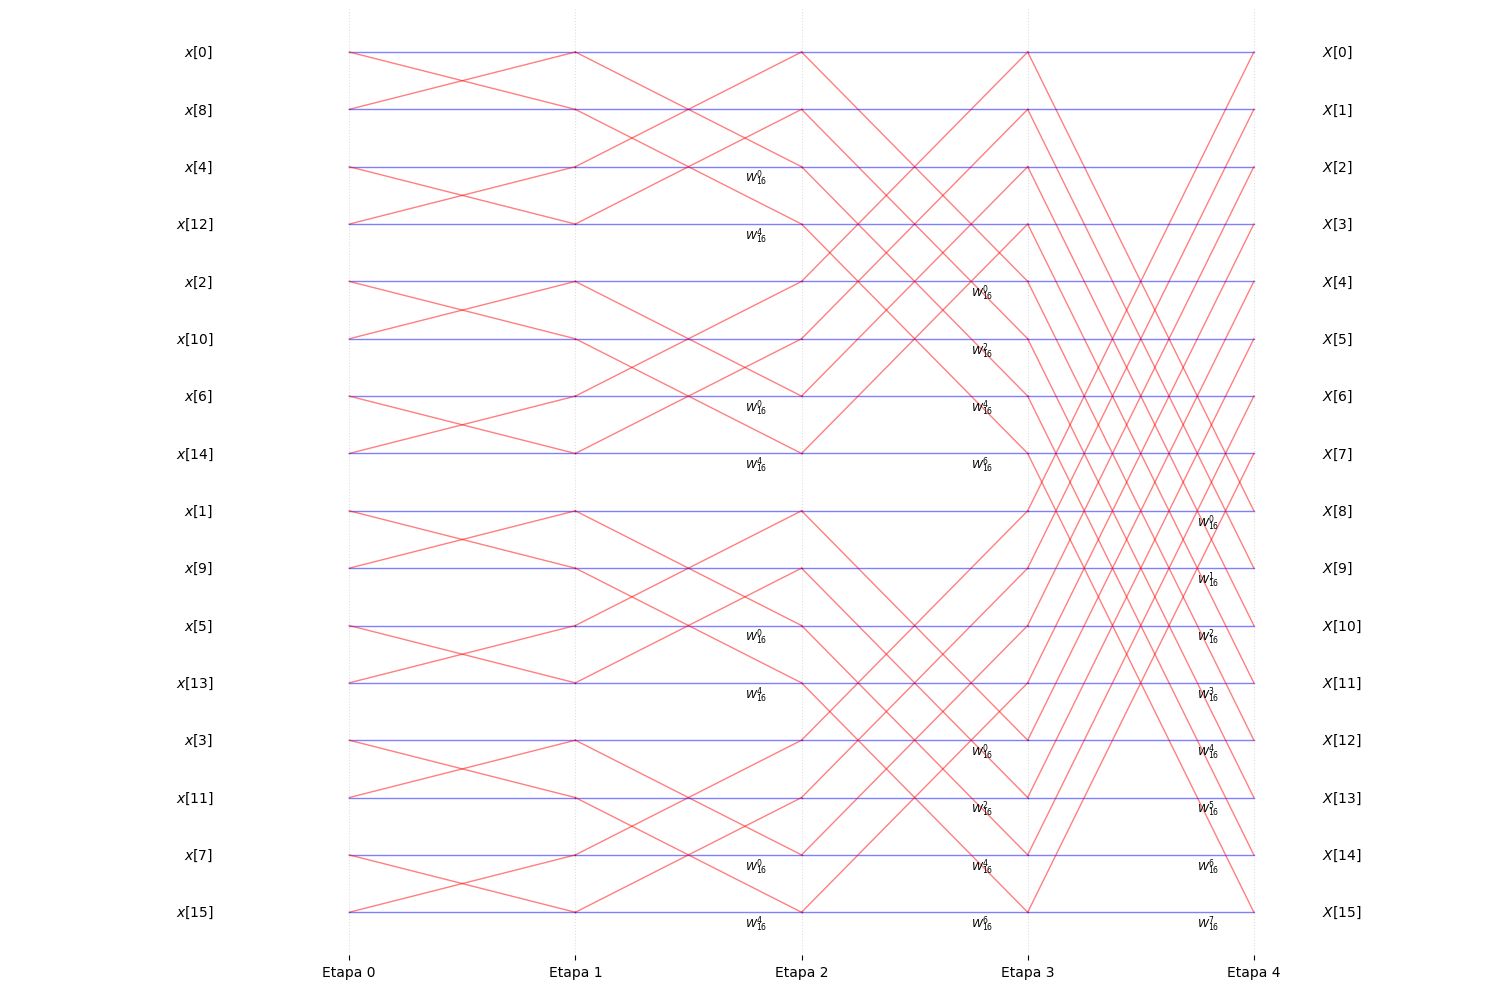

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def draw_fft_16_points():
    N = 16
    stages = int(np.log2(N))  # 4 etapas para N=16
    fig, ax = plt.subplots(figsize=(15, 10))

    # 1. Función para inversión de bits (4 bits para N=16)
    def bit_reverse(n, bits):
        return int('{:0{b}b}'.format(n, b=bits)[::-1], 2)

    # 2. Dibujar líneas y mariposas
    for stage in range(stages):
        step = 2**stage
        group_size = step * 2
        w_step = N // group_size

        for i in range(0, N, group_size):
            for j in range(step):
                idx_top = i + j
                idx_bot = i + j + step

                # Coordenadas (X=etapa, Y=índice invertido para que 0 esté arriba)
                x_start, x_end = stage, stage + 1
                y_top, y_bot = N - 1 - idx_top, N - 1 - idx_bot

                # Dibujar líneas de la mariposa
                # Azul para líneas rectas, Rojo para las cruzadas
                ax.plot([x_start, x_end], [y_top, y_top], 'b-', alpha=0.5, linewidth=1)
                ax.plot([x_start, x_end], [y_bot, y_top], 'r-', alpha=0.5, linewidth=1)
                ax.plot([x_start, x_end], [y_bot, y_bot], 'b-', alpha=0.5, linewidth=1)
                ax.plot([x_start, x_end], [y_top, y_bot], 'r-', alpha=0.5, linewidth=1)

                # Etiquetar factores de giro (W) solo en las líneas que multiplican [cite: 21, 22]
                if stage > 0: # Para mayor claridad visual en N=16
                    ax.text(x_start + 0.75, y_bot - 0.25, f'$W_{{16}}^{{{j * w_step}}}$', fontsize=8)

    # 3. Etiquetas de entrada y salida
    for i in range(N):
        rev_i = bit_reverse(i, stages)
        # Entrada en Bit-Reversal
        ax.text(-0.6, N - 1 - i, f'$x[{rev_i}]$', ha='right', va='center', fontsize=10, fontweight='bold')
        # Salida en orden natural [cite: 23]
        ax.text(stages + 0.3, N - 1 - i, f'$X[{i}]$', ha='left', va='center', fontsize=10, fontweight='bold')

    # Configuración estética
    #ax.set_title(f"Diagrama de Flujo de Señal - FFT Radix-2 ($N=16$ puntos, 4 etapas)", fontsize=16)
    ax.set_xticks(range(stages + 1))
    ax.set_xticklabels([f"Etapa {i}" for i in range(stages + 1)])
    ax.set_yticks([])
    ax.set_xlim(-1.5, stages + 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()

draw_fft_16_points()

Diagrama en N = 1024, pero solo con la mitad de etapas visibles

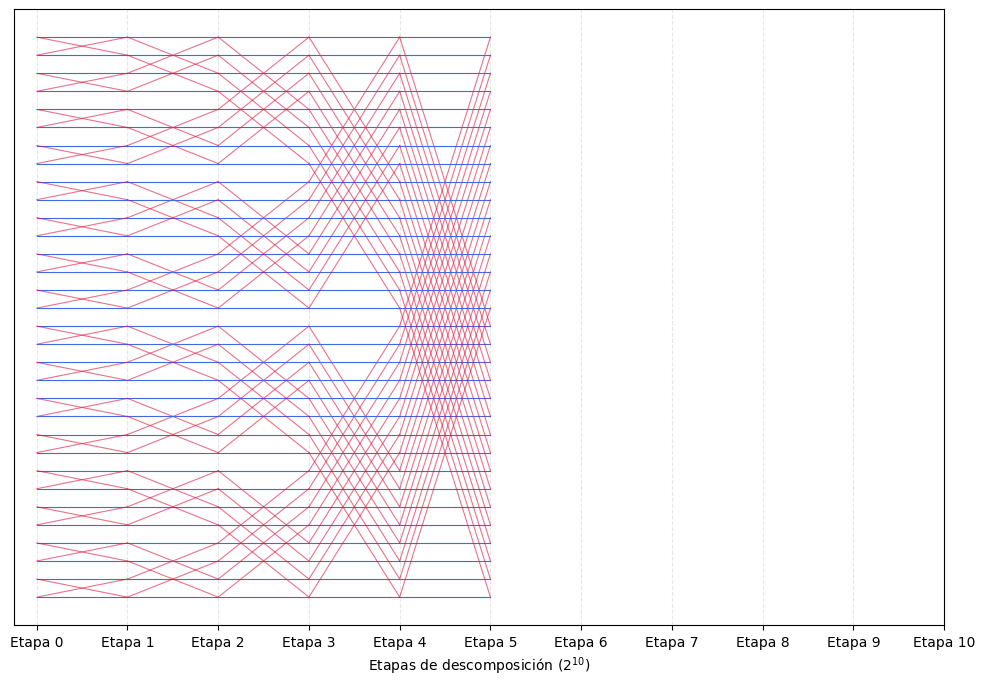

In [7]:
def draw_fft_zoom(N_total=1024, muestras_a_ver=32):
    stages = int(np.log2(N_total)) # 10 etapas
    fig, ax = plt.subplots(figsize=(12, 8))

    # Dibujamos solo un segmento para que sea legible
    for stage in range(stages):
        step = 2**stage
        group_size = step * 2

        # Solo iteramos en el rango de muestras que queremos ver
        for i in range(0, muestras_a_ver, group_size):
            for j in range(step):
                idx_top = i + j
                idx_bot = i + j + step

                # Evitamos que el dibujo se salga del "zoom"
                if idx_bot >= muestras_a_ver:
                    continue

                x_start, x_end = stage, stage + 1
                y_top, y_bot = muestras_a_ver - 1 - idx_top, muestras_a_ver - 1 - idx_bot

                # Líneas más gruesas (0.8) y colores sólidos
                ax.plot([x_start, x_end], [y_top, y_top], color='royalblue', linewidth=0.8)
                ax.plot([x_start, x_end], [y_bot, y_top], color='crimson', linewidth=0.8, alpha=0.6)
                ax.plot([x_start, x_end], [y_bot, y_bot], color='royalblue', linewidth=0.8)
                ax.plot([x_start, x_end], [y_top, y_bot], color='crimson', linewidth=0.8, alpha=0.6)

    #ax.set_title(f"Detalle Estructural de la FFT de {N_total} puntos (Muestras 0-{muestras_a_ver-1})", fontsize=14)
    ax.set_xticks(range(stages + 1))
    ax.set_xticklabels([f"Etapa {i}" for i in range(stages + 1)])
    ax.set_xlabel("Etapas de descomposición ($2^{10}$)")
    ax.set_yticks([])
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.show()

draw_fft_zoom(1024, 32)